In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Read in data
project_path = Path("../data/Broad/BBBC014/").resolve()

In [13]:
# Summary
summary = pd.read_csv(project_path / "summary_predictions.csv")
summary["plate_row"] = summary["file"].apply(lambda x: x.split("-")[1])
summary["plate_col"] = summary["file"].apply(lambda x: x.split("-")[2])
summary["cell_line"] = summary["plate_row"].apply(lambda x: "MCF7" if x in ["A", "B", "C", "D"] else "A549")
list_of_keys_values = {1:-7, 2: -7.523, 3: -8, 4: -8.523, 5: -9, 6: -9.523, 7: -10, 8: -10.523, 9: -11, 10: -11.523, 11: -12, 12: 0}
summary["dose"] = summary["plate_col"].apply(lambda x: list_of_keys_values[int(x)])
summary


,file,0,1,2,4,cells_with_micronuclei,cells_with_micronuclei_ratio,micronuclei_ratio,total_cells,total_micronuclei,plate_row,plate_col,cell_line,dose
0,01-A-01-00,583.0,NaN,NaN,NaN,0.0,0.000000,0.000000,583.0,0.0,A,01,MCF7,-7.000
1,02-A-02-00,708.0,15.0,NaN,NaN,15.0,0.020747,0.020747,723.0,15.0,A,02,MCF7,-7.523
2,03-A-03-00,616.0,3.0,NaN,NaN,3.0,0.004847,0.004847,619.0,3.0,A,03,MCF7,-8.000
3,04-A-04-00,716.0,9.0,NaN,NaN,9.0,0.012414,0.012414,725.0,9.0,A,04,MCF7,-8.523
4,05-A-05-00,626.0,5.0,NaN,NaN,5.0,0.007924,0.007924,631.0,5.0,A,05,MCF7,-9.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91,92-H-08-00,407.0,12.0,NaN,NaN,12.0,0.028640,0.028640,419.0,12.0,H,08,A549,-10.523
92,93-H-09-00,381.0,6.0,1.0,NaN,7.0,0.018041,0.020619,388.0,8.0,H,09,A549,-11.000
93,94-H-10-00,443.0,8.0,NaN,NaN,8.0,0.017738,0.017738,451.0,8.0,H,10,A549,-11.523
94,95-H-11-00,424.0,8.0,NaN,NaN,8.0,0.018519,0.018519,432.0,8.0,H,11,A549,-12.000


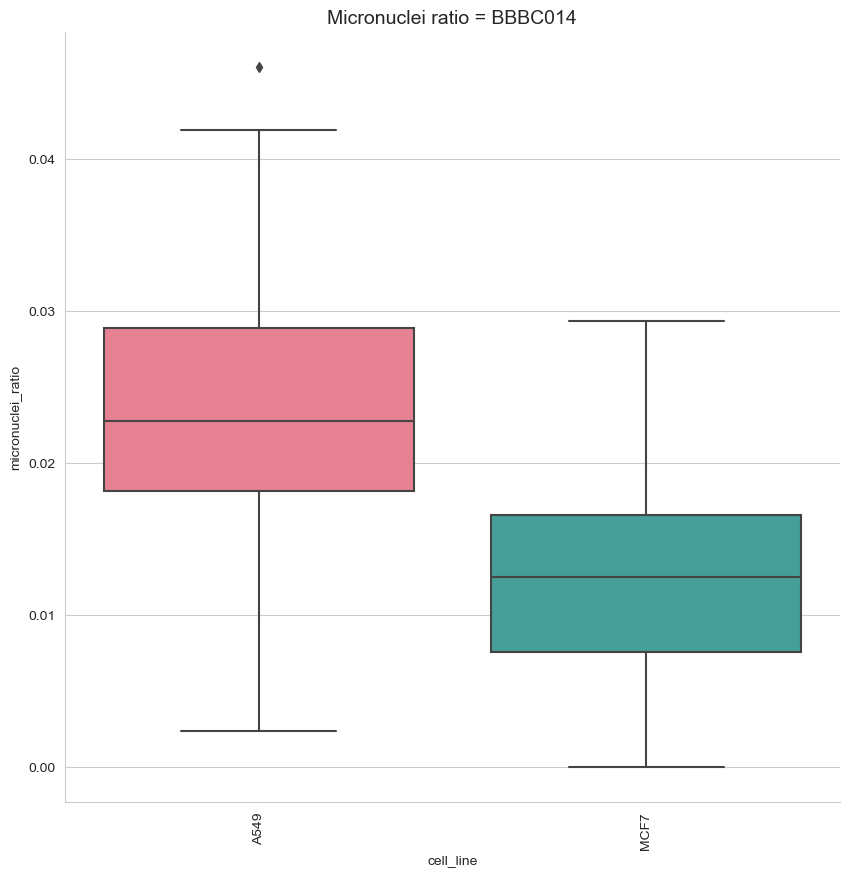

In [44]:
# Plot scatterplot of the micronuclei_ratio
fig, ax = plt.subplots(figsize=(10, 10))
# Sort results by the micronuclei_ratio
results = summary.sort_values(by="micronuclei_ratio", ascending=False)
sns.boxplot(data=results, x="cell_line",  y="micronuclei_ratio", palette="husl", ax=ax)

# Rotate the 90 degrees the x-axis labels
plt.xticks(rotation=90)

ax.set_title(f"Micronuclei ratio = BBBC014", fontsize=14)

sns.despine()
fig.savefig(project_path / "figures" / "micronuclei_ratio_by_cell_line.png", dpi=300, bbox_inches="tight")
fig.savefig(project_path / "figures" / "micronuclei_ratio_by_cell_line.pdf", dpi=300, bbox_inches="tight")

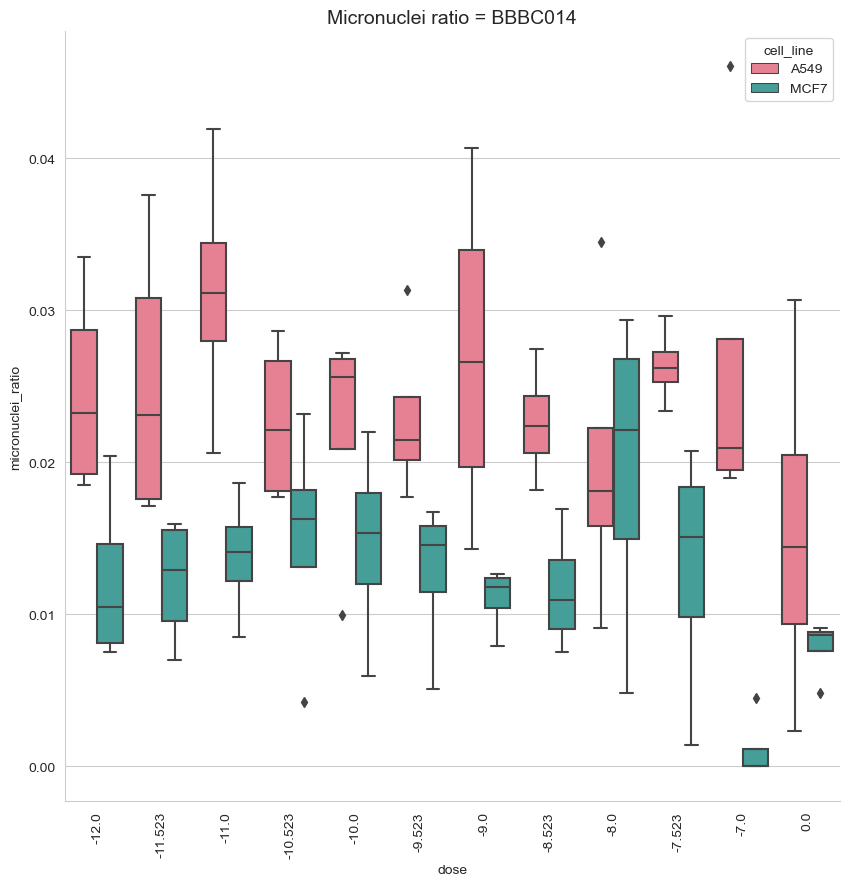

In [45]:
# Plot scatterplot of the micronuclei_ratio
fig, ax = plt.subplots(figsize=(10, 10))
# Sort results by the micronuclei_ratio
results = summary.sort_values(by="micronuclei_ratio", ascending=False)
sns.boxplot(data=results, x="dose",  y="micronuclei_ratio",  hue="cell_line",palette="husl", ax=ax)

# Rotate the 90 degrees the x-axis labels
plt.xticks(rotation=90)

ax.set_title(f"Micronuclei ratio = BBBC014", fontsize=14)

sns.despine()
fig.savefig(project_path / "figures" / "micronuclei_ratio_by_dose.png", dpi=300, bbox_inches="tight")
fig.savefig(project_path / "figures" / "micronuclei_ratio_by_dose.pdf", dpi=300, bbox_inches="tight")

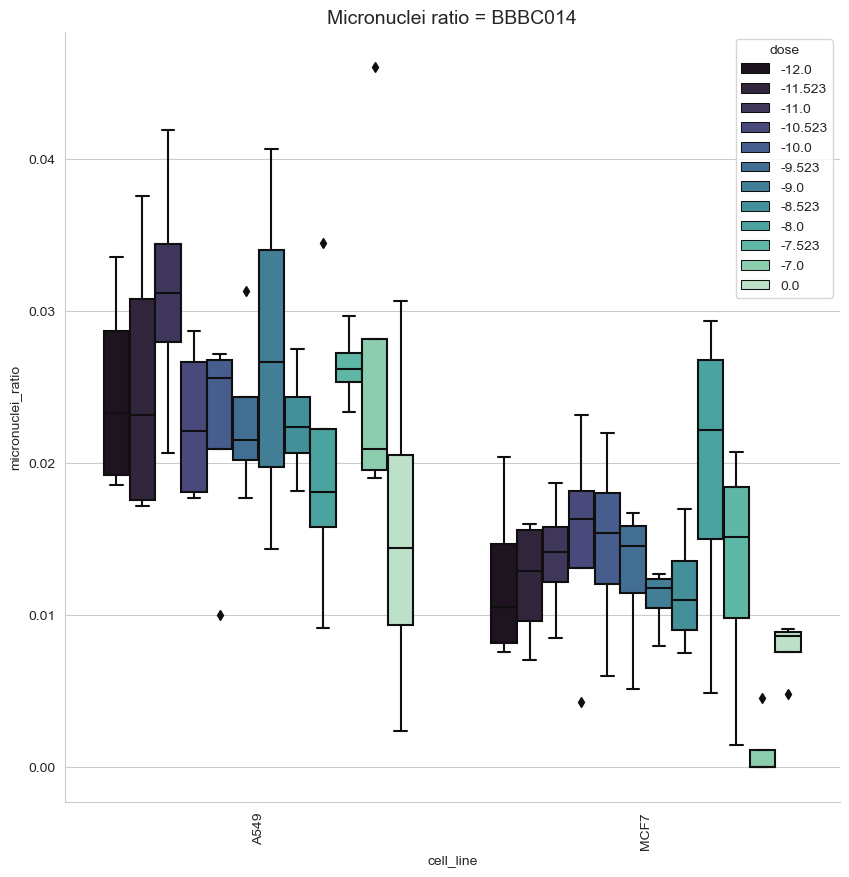

In [55]:
# Plot scatterplot of the micronuclei_ratio
fig, ax = plt.subplots(figsize=(10, 10))
# Sort results by the micronuclei_ratio
results = summary.sort_values(by="micronuclei_ratio", ascending=False)
sns.boxplot(data=results, x="cell_line",  y="micronuclei_ratio",  hue="dose", palette="mako", ax=ax)

# Rotate the 90 degrees the x-axis labels
plt.xticks(rotation=90)

ax.set_title(f"Micronuclei ratio = BBBC014", fontsize=14)

sns.despine()
fig.savefig(project_path / "figures" / "micronuclei_ratio_by_dose2.png", dpi=300, bbox_inches="tight")
fig.savefig(project_path / "figures" / "micronuclei_ratio_by_dose2.pdf", dpi=300, bbox_inches="tight")